**Universidad Nacional Autónoma de México \- Facultad de Ingeniería \- Profesor: M.I. Erik Peña Medina**

# <span style="color:rgb(213,80,0)">Proyecto:Introducción al Modelado Espacial de Robots</span>

**Alumnos:**

 **Cruz Zamora Franco Sebastián**

**Franco Ayala Carlos Alfonso**

**Manzano Martinez Nancy**

 **Nava Hernández Gerardo Saúl**

**Ortiz Carreño Fabian**

## Resumen

El presente proyecto tiene como objetivo el desarrollo del modelo dinámico completo de un robot manipulador de 3 grados de libertad (3R) tipo RoArm, empleando el formalismo de Euler\-Lagrange como herramienta matemática principal. Este tipo de modelado es fundamental en robótica, ya que permite conocer las fuerzas y pares necesarios para controlar el movimiento del robot en el espacio tridimensional, considerando tanto los efectos inerciales como los gravitacionales y las fuerzas de Coriolis.

**Obtención de parámetros:**Como primera etapa, se extrajeron las propiedades físicas de cada uno de los eslabones que conforman el robot directamente desde el software de diseño asistido por computadora Autodesk Inventor, haciendo uso de la herramienta de Propiedades Físicas (iProperties). Los parámetros obtenidos incluyen la masa de cada eslabón, las coordenadas del centro de gravedad en los tres ejes, y los momentos másicos de inercia respecto al centro de gravedad (Ixx, Iyy, Izz). Dado que el modelo dinámico requiere que los centros de masa estén expresados en coordenadas relativas a cada articulación y no al origen global del ensamble, se realizó una corrección de los valores del centro de gravedad en el eje Z, restando el offset correspondiente a la posición de cada motor medido desde la base del robot. Todas las unidades fueron convertidas al Sistema Internacional (kilogramos, metros, segundos).

**Modelado cinemático de posición:** En la segunda etapa se construyó el modelo cinemático del robot mediante transformadas homogéneas, siguiendo la convención de rotaciones ZYX. Se definieron las matrices de transformación entre cada par de eslabones consecutivos (T₀₁, T₁₂, T₂₃, T₃ₚ), y mediante su producto encadenado se obtuvo la transformada total T₀ₚ que describe la posición y orientación del efector final respecto a la base. A partir de esta transformada se extrajo el vector de postura del robot y el vector de posición del efector final p₀ₚ.

 **Modelado cinemático de velocidades:** Se calculó el Jacobiano geométrico del robot J(θ) mediante diferenciación del vector de posición respecto a las coordenadas generalizadas. El determinante del Jacobiano fue evaluado simbólicamente para identificar las configuraciones singulares del robot, es decir, aquellas posiciones en las que el robot pierde uno o más grados de libertad. Adicionalmente se calcularon las velocidades angulares de cada eslabón mediante propagación desde la base hasta el efector final.

**Modelado dinámico Mediante Euler\-Lagrange:** En la etapa central del proyecto se aplicó el formalismo de Lagrange para obtener las ecuaciones de movimiento del robot. Para cada eslabón se calcularon su posición del centro de masa respecto al marco inercial, su velocidad lineal y su velocidad angular. Con estos elementos se formularon las energías cinéticas traslacional y rotacional de cada eslabón, así como las energías potenciales gravitacionales. El Lagrangeano del sistema se obtuvo como la diferencia entre la energía cinética total y la energía potencial total. Aplicando las ecuaciones de Euler\-Lagrange se derivaron los pares generalizados τ₁, τ₂ y τ₃ correspondientes a cada articulación, y mediante sustituciones selectivas se identificaron y separaron las tres matrices fundamentales del modelo dinámico:

- **M(q):** Matriz de inercia del robot, simétrica y definida positiva, que relaciona las aceleraciones articulares con los pares necesarios.
- **V(q,q̇):** Vector de fuerzas de Coriolis y centrífugas, que depende tanto de las posiciones como de las velocidades articulares.
- **G(q):** Vector de fuerzas gravitacionales, que representa los pares necesarios para sostener el robot en una posición dada contra la gravedad.

**Sustitución de parámetros y validación:** Finalmente, los parámetros físicos obtenidos del robot RoArm fueron sustituidos en el modelo dinámico simbólico, obteniendo expresiones numéricas en función únicamente de las coordenadas generalizadas. El modelo fue evaluado numéricamente en la configuración de referencia (θ₁ = θ₂ = θ₃ = 0, θ̇₁ = θ̇₂ = θ̇₃ = 0), obteniendo la matriz de inercia numérica M(q₀), así como los vectores V(q₀,0) = 0 y G(q₀) = 0, resultados coherentes con la física del sistema en dicha configuración.

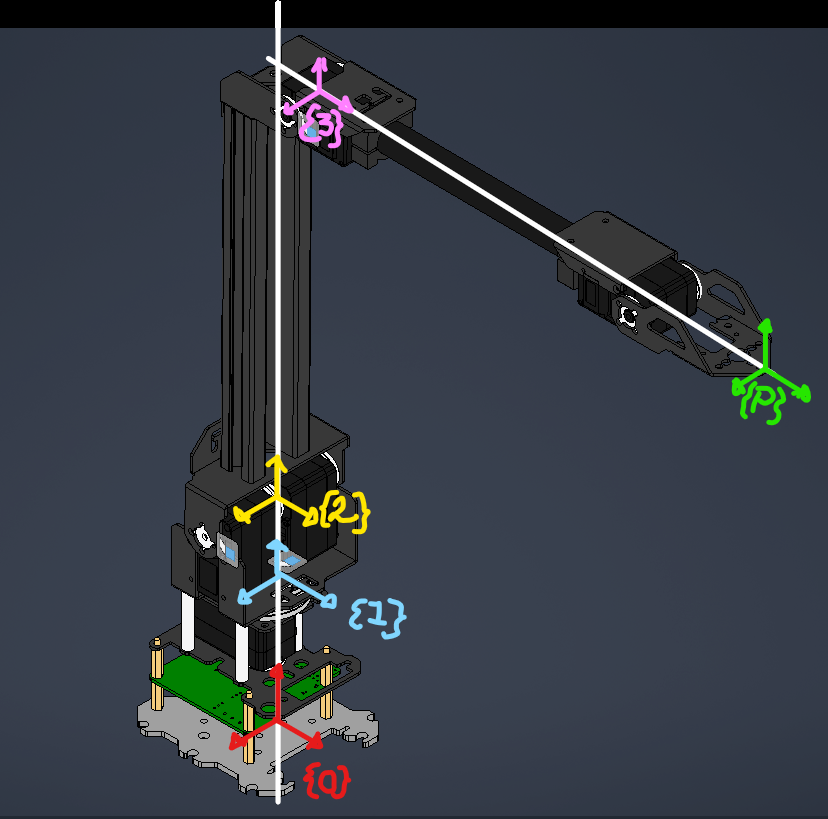

*Imagen 1: Diagrama de coordenadas asignado para el RoArm*

## Trasformada homogenea

En robótica, para describir la posición y orientación de un eslabón respecto a otro se utilizan las **transformadas homogéneas**, que son matrices de 4×4 que combinan en una sola operación tanto la rotación como la traslación entre dos sistemas de referencia consecutivos.

En este proyecto se define una función simbólica general `Tij` que recibe seis parámetros: las traslaciones en X, Y y Z, y los ángulos de rotación gamma (γ), beta (β) y alfa (α), siguiendo la convención de rotaciones **ZYX** (también conocida como ángulos de Euler). La matriz resultante tiene la forma:


In [1]:
%T = | R  p |
%    | 0  1 |


Donde **R** es la matriz de rotación 3×3 que describe la orientación relativa entre dos eslabones, y **p** es el vector de posición 3×1 que indica la traslación entre sus orígenes.

Esta función es la piedra angular de todo el proyecto, ya que será reutilizada a lo largo del código para construir todas las transformadas entre eslabones, calcular las posiciones de los centros de masa, y derivar tanto el modelo cinemático como el dinámico del robot. Cada vez que se llame a `Tij` con parámetros específicos, se estará describiendo cómo se mueve y rota un eslabón respecto al anterior.


In [2]:
syms Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j)


% Homogeneous transform
Tij(x_i_j,y_i_j,z_i_j,gi_j,bi_j,ai_j) = [cos(ai_j)*cos(bi_j) cos(ai_j)*sin(bi_j)*sin(gi_j)-sin(ai_j)*cos(gi_j) sin(ai_j)*sin(gi_j)+cos(ai_j)*sin(bi_j)*cos(gi_j) x_i_j; sin(ai_j)*cos(bi_j) cos(ai_j)*cos(gi_j)+sin(ai_j)*sin(bi_j)*sin(gi_j) sin(ai_j)*sin(bi_j)*cos(gi_j)-cos(ai_j)*sin(gi_j) y_i_j; -sin(bi_j) cos(bi_j)*sin(gi_j) cos(bi_j)*cos(gi_j) z_i_j; 0 0 0 1]


`Se define de forma simbólica las dimensiones fijas y longitudes de cada eslabón del robot, las cuales usarás para calcular los desplazamientos entre cada articulación.`

## Modelado de la posición del robot 3R

Una vez definida la transformada homogénea general, se procede a construir el modelo de posición del robot. Para ello se definen dos tipos de variables simbólicas:

- **Parámetros geométricos:** `z_O_1`, `z_1_2`, `z_2_3`, `z_3_P`, que representan las distancias entre articulaciones consecutivas a lo largo del eje Z de cada eslabón. Estos valores corresponden a las longitudes físicas medidas del robot RoArm.
- **Grados de libertad:** `theta_O_1`, `theta_1_2`, `theta_2_3`, que son los ángulos de rotación de cada articulación y constituyen las coordenadas generalizadas del sistema. Estos son los valores que cambian durante el movimiento del robot.

Con estas variables se construyen las transformadas homogéneas individuales entre cada par de eslabones consecutivos:


In [3]:
syms z_O_1 z_1_2 z_2_3 z_3_P  %parametros
syms theta_O_1 theta_1_2 theta_2_3 %grados de libertad
%T_O_1 → rotación en Z (cintura)
T_O_1 = Tij(0,0,z_O_1,0,0,theta_O_1)


`Se calcula la matriz de transformación homogénea de la base al primer eslabón (cintura). Aplica una traslación en Z de altura z_0_1 y una rotación en el eje Z controlada por el ángulo de la articulación theta_0_1.`


In [4]:
%T_1_2 → rotación en Y (hombro)
T_1_2 = Tij(0,0,z_1_2,0,theta_1_2,0)


`Calcula la matriz de transformación del primer al segundo eslabón (hombro). Aplica una traslación en Z de longitud z_1_2 y una rotación alrededor del eje Y local controlada por el ángulo theta_1_2.`


In [5]:
%T_2_3 → rotación en Y (codo)
T_2_3 = Tij(0,0,z_2_3,0,theta_2_3,0)


`Calcula la matriz de transformación del segundo al tercer eslabón (codo). Desplaza el sistema una distancia z_2_3 en el eje Z y aplica una rotación en el eje Y local controlada por el ángulo theta_2_3.`


In [6]:
%T_3_P → traslación pura hacia el efector final
T_3_P = Tij(0,0,z_3_P,0,0,0)


Nótese que la primera articulación rota sobre el eje Z porque es la que permite girar horizontalmente al robot (cintura), mientras que las articulaciones 2 y 3 rotan sobre el eje Y porque generan movimiento en el plano vertical (elevación del brazo).

Finalmente, la transformada total del robot desde la base hasta el efector final se obtiene multiplicando encadenadamente todas las transformadas individuales:


In [7]:
%T_O_P = T_O_1 · T_1_2 · T_2_3 · T_3_P
T_O_P = simplify(T_O_1*T_1_2*T_2_3*T_3_P)


Esta matriz 4×4 contiene toda la información necesaria para conocer en cualquier instante dónde se encuentra el efector final del robot y con qué orientación, dados los ángulos de las tres articulaciones. A partir de ella se extrae el **vector de postura** `xi_O_P` que resume en 6 componentes la posición (x, y, z) y orientación del efector, y el **vector de posición** `p_O_P` que contiene únicamente las coordenadas cartesianas del efector final.

**Vector de postura**


In [8]:
xi_O_P = [T_O_P(1,4); T_O_P(2,4); T_O_P(3,4); T_O_P(1,1); T_O_P(2,2); T_O_P(3,3)]


`Construye el vector de postura del efector final. Extrae de la matriz de transformación total T_0_P los primeros tres elementos de la cuarta columna para obtener las coordenadas de posición cartesiana` *`(x, y, z)`* `y, posteriormente, extrae los componentes clave de la matriz de rotación para definir la orientación espacial del extremo del brazo robot en una sola matriz columna de` ***`6x1`***`.`


In [9]:
p_O_P = [T_O_P(1,4); T_O_P(2,4); T_O_P(3,4)]


`Extrae únicamente el vector de posición cartesiana` *`(x, y, z)`* `del efector final a partir de la cuarta columna de la matriz de transformación total T_0_P. A diferencia de la celda anterior (xi_0_P), este vector es de tamaño` ***`3x1`*** `y sirve exclusivamente para aislar las coordenadas lineales de la punta del brazo robot, dejando de lado la orientación. Esto es el paso previo y fundamental que necesitas para calcular el Jacobiano geométrico.`

## Modelo cinemático directo de las velocidades

Conocer la posición del efector final en función de los ángulos articulares es útil, pero en la práctica también es necesario relacionar las **velocidades articulares** (qué tan rápido giran los motores) con la **velocidad del efector final** (qué tan rápido se mueve la herramienta en el espacio). Esta relación la establece el **Jacobiano geométrico** J(θ).

El Jacobiano es una matriz de 3×3 que se obtiene diferenciando el vector de posición del efector `p_O_P` respecto a cada una de las coordenadas generalizadas:

**v\_efector = J(θ) · θ**̇

donde:

v\_efector → velocidad cartesiana del efector \[3×1\]

J(θ)      → matriz Jacobiana              \[3×3\]

θ̇         → velocidades articulares       \[3×1\]

**Calculo del Jacobino**

En el código se calcula usando la función `jacobian` de MATLAB, que realiza automáticamente todas las derivadas parciales simbólicas.


In [10]:


%J_theta = simplify(jacobian(xi_O_P,[theta_O_1,theta_1_2, theta_2_3]))
J_theta = simplify(jacobian(p_O_P, [theta_O_1, theta_1_2, theta_2_3]));




 `La matriz Jacobiana geométrica` ***`3x3`*** `del robot RoArm. Lo que hace internamente es obtener las derivadas parciales del vector de posición lineal p_0_P respecto a cada una de las variables articulares` *`(`****θ\_1, θ\_2****`,`****θ\_3****`)`* `.`

**Determinante del Jacobiano**

Un resultado particularmente importante es el **determinante de J(θ)**. Este valor indica si el robot se encuentra en una **configuración singular**, es decir, una posición en la que el robot pierde la capacidad de moverse en alguna dirección del espacio, sin importar qué tan rápido giren sus motores. Matemáticamente esto ocurre cuando:

det(J(θ)) = 0  →  configuración singular  ️

det(J(θ)) ≠ 0  →  configuración regular

Las singularidades son críticas en el diseño de trayectorias del robot porque en esas configuraciones el control se vuelve inestable y pueden generarse velocidades articulares infinitas.


In [11]:
det(J_theta)


### Modelo cinemático inverso de las velocidades

La pseudoinversa del Jacobiano se presenta  como referencia para el modelo cinemático  inverso de velocidades. Su cálculo simbólico  completo queda fuera del alcance de este  proyecto debido a su complejidad computacional,  sin embargo su formulación es:si


In [12]:
%J_theta_psin = pinv(J_theta)


## Modelo dinámico del robot en el espacio

El modelo dinámico es la parte central del proyecto. A diferencia del modelo cinemático que solo describe **dónde está** y **cómo se mueve** el robot, el modelo dinámico responde a la pregunta fundamental del control: **¿cuánta fuerza o par debe aplicar cada motor para lograr un movimiento deseado?**

Para obtener este modelo se utiliza el **formalismo de Euler\-Lagrange**, que es un enfoque energético basado en dos conceptos:

Energía cinética  K → energía del movimiento

Energía potencial U → energía almacenada por gravedad

Lagrangeano: L = K \- U

**Cálculo de los Centros de Masa de los Eslabones**

Para cada eslabón se define una transformada homogénea adicional `T_i_Ci` que ubica el centro de masa del eslabón i respecto a su propia articulación, usando los valores `z_1_C1`, `z_2_C2`, `z_3_C3` obtenidos y corregidos del robot RoArm. Combinando esta transformada con las del modelo cinemático se obtiene la posición de cada centro de masa respecto al marco inercial de la base `p_O_Ci`. Finalmente, las velocidades lineales de cada centro de masa `v_O_Ci` se obtienen diferenciando su posición respecto a cada coordenada generalizada activa.


In [13]:
syms theta_dot_O_1 theta_dot_1_2 theta_dot_2_3 z_1_C1 z_2_C2 z_3_C3


T_1_C1 = Tij(0,0,z_1_C1,0,0,0)

In [14]:


T_O_C1 = simplify(T_O_1*T_1_C1);


p_O_C1 = [T_O_C1(1,4); T_O_C1(2,4); T_O_C1(3,4)]

In [15]:


v_O_C1 = diff(p_O_C1, theta_O_1)*theta_dot_O_1


`El vector de velocidad lineal del primer centro de masa mediante la regla de la cadena. Deriva de forma parcial el vector de posición p_0_C1 con respecto al ángulo theta_0_1 (usando diff) y lo multiplica por su velocidad articular (theta_dot_0_1). Como es el primer eslabón, su salida da un vector de ceros` `[0; 0; 0]` `porque físicamente ese centro de masa solo rota sobre el eje inercial Z y no se traslada espacialmente.`


In [16]:
%


T_2_C2 = Tij(0,0,z_2_C2,0,0,0)

In [17]:


T_O_C2 = simplify(T_O_1*T_1_2*T_2_C2);


p_O_C2 = [T_O_C2(1,4); T_O_C2(2,4); T_O_C2(3,4)]


`Con esto se obtiene la posición y orientación de ese punto con respecto al marco inercial fijo.`


In [18]:
v_O_C2 = diff(p_O_C2, theta_O_1)*theta_dot_O_1 + diff(p_O_C2, theta_1_2)*theta_dot_1_2


`El vector de velocidad lineal del segundo centro de masa. Como este punto ya se ve afectado por el movimiento de las primeras dos articulaciones, aplica la regla de la cadena completa sumando las derivadas parciales de p_0_C2 respecto a theta_0_1 y theta_1_2, multiplicadas por sus respectivas velocidades articulares.`


In [19]:
%


T_3_C3 = Tij(0,0,z_3_C3,0,0,0)


`La matriz de transformación homogénea local para el centro de masa del tercer eslabón (codo) respecto a su propia articulación. Aplica únicamente una traslación de distancia z_3_C3 en su eje Z local sin añadir rotaciones.`


In [20]:
T_O_C3 = simplify(T_O_1*T_1_2*T_2_3*T_3_C3);


p_O_C3 = [T_O_C3(1,4); T_O_C3(2,4); T_O_C3(3,4)]


`La matriz de transformación homogénea total para el tercer centro de masa multiplicando en cadena todas las transformaciones acumuladas desde la base fija del robot.`


In [21]:
v_O_C3 = diff(p_O_C3, theta_O_1)*theta_dot_O_1 + diff(p_O_C3, theta_1_2)*theta_dot_1_2 + diff(p_O_C3, theta_2_3)*theta_dot_2_3


`Vector de velocidad lineal del tercer centro de masa. Al ser el último cuerpo del brazo, su movimiento depende de las tres articulaciones, por lo que aplica la regla de la cadena sumando las derivadas parciales de p_0_C3 respecto a theta_0_1, theta_1_2 y theta_2_3, multiplicadas por sus velocidades de giro.`

**Propagación de las Velocidades Angulares**

Las velocidades angulares de cada eslabón no se pueden obtener simplemente diferenciando posiciones, ya que están expresadas en marcos de referencia distintos. Por ello se utiliza el método de propagación, que parte de la base con velocidad angular cero y va acumulando la contribución de cada articulación usando las matrices de rotación inversas entre eslabones. Los vectores `nu_1`, `nu_2`, `nu_3` indican el eje de giro de cada articulación en su propio marco de referencia:

nu\_1 = \[0;0;1\] → cintura gira sobre Z

nu\_2 = \[0;1;0\] → antebrazo gira sobre Y

nu\_3 = \[0;1;0\] → brazo gira sobre Y


In [22]:
% Matrices de Rotación


R_O_1 = [T_O_1(1,1),T_O_1(1,2),T_O_1(2,3); T_O_1(2,1),T_O_1(1,2),T_O_1(2,3);T_O_1(3,1),T_O_1(3,2),T_O_1(3,3)];
R_1_O = transpose(R_O_1)


`Extrae la matriz de rotación del eslabón 1 y obtiene su transpuesta (inversa) para transformar vectores del marco de la base al marco local 1.`


In [23]:
R_1_2 = [T_1_2(1,1),T_1_2(1,2),T_1_2(2,3); T_1_2(2,1),T_1_2(1,2),T_1_2(2,3);T_1_2(3,1),T_1_2(3,2),T_1_2(3,3)];
R_2_1 = transpose(R_1_2)


`Extrae la matriz de rotación del eslabón 2 y obtiene su transpuesta para transformar vectores del marco local 1 al marco local 2.`


In [24]:
R_2_3 = [T_2_3(1,1),T_2_3(1,2),T_2_3(2,3); T_2_3(2,1),T_2_3(1,2),T_2_3(2,3);T_2_3(3,1),T_2_3(3,2),T_2_3(3,3)];
R_3_2 = transpose(R_2_3)


`La matriz de rotación del eslabón 3 y se obtiene su transpuesta para transformar vectores del marco local 2 al marco local 3.`


In [25]:
% calculo de las velocidades angulares
omega_O_O = [0;0;0];
nu_1 = [0;0;1];
omega_1_1 = R_O_1*omega_O_O + nu_1*theta_dot_O_1


`Define la base fija (omega_0_0 = 0) y el eje de giro Z para la cintura (nu_1). Calcula la velocidad angular del eslabón 1 sumando la velocidad arrastrada y la propia.`


In [26]:
nu_2 = [0;1;0];
omega_2_2 = R_2_1*omega_1_1 + nu_2*theta_dot_1_2

In [27]:


nu_3 = [0;1;0];
omega_3_3 = R_3_2*omega_2_2 + nu_3*theta_dot_2_3


**Matrices de Inercia**

Las matrices de inercia de cada eslabón se definen como matrices diagonales 3×3, asumiendo que los ejes del modelo coinciden con los ejes principales de inercia de cada pieza. Los valores de la diagonal `Ixx`, `Iyy`, `Izz` fueron obtenidos directamente de Inventor para cada eslabón del robot RoArm.


In [28]:
syms I_xx1 I_yy1 I_zz1 I_xx2 I_yy2 I_zz2 I_xx3 I_yy3 I_zz3


I_C1 = [I_xx1, 0, 0; 0, I_yy1, 0; 0, 0, I_zz1]


`Se declara los momentos de inercia y construye el tensor de inercia local (matriz diagonal 3x3) para el eslabón 1, asumiendo los ejes principales del cuerpo.`


In [29]:
I_C2 = [I_xx2, 0, 0; 0, I_yy2, 0; 0, 0, I_zz2]

In [30]:
I_C3 = [I_xx3, 0, 0; 0, I_yy3, 0; 0, 0, I_zz3]


**Cálculo del Lagrangeano**

Con todos los elementos anteriores se calculan las energías del sistema. La energía cinética de cada eslabón tiene dos componentes, la traslacional asociada al movimiento de su centro de masa, y la rotacional asociada a su velocidad angular. La energía potencial de cada eslabón depende de la altura de su centro de masa respecto al plano de referencia. El Lagrangeano total es la diferencia entre la suma de energías cinéticas y la suma de energías potenciales.


In [31]:
syms m_1 m_2 m_3 g


% energía cinetica
k_1 = 1/2*m_1*transpose(v_O_C1)*v_O_C1 + transpose(omega_1_1)*I_C1*omega_1_1


`Declara simbólicamente las masas y la gravedad.`

`Calcula la energía cinética total del eslabón 1 (traslacional + rotacional).`


In [32]:
k_2 = 1/2*m_2*transpose(v_O_C2)*v_O_C2 + transpose(omega_2_2)*I_C2*omega_2_2

In [33]:
k_3 = 1/2*m_3*transpose(v_O_C3)*v_O_C3 + transpose(omega_3_3)*I_C1*omega_3_3


`Calcula de forma algebraica la energía cinética total del tercer eslabón (k_3) sumando la energía traslacional de su centro de masa y la rotacional en 3D basada en su tensor de inercia y su velocidad angular acumulada.`


In [34]:
% energía potencial
g_O = [0;0;-g];


u_1 = -m_1*transpose(p_O_C1)*g_O


`Define el vector de aceleración de la gravedad orientado en el sentido negativo del eje Y inercial. Calcula la energía potencial gravitacional del primer eslabón (u_1) multiplicando la masa por el producto punto entre la altura de su centro de masa (p_0_C1) y el vector de gravedad.`


In [35]:
u_2 = -m_2*transpose(p_O_C2)*g_O

In [36]:
u_3 = -m_3*transpose(p_O_C3)*g_O

In [37]:
% lagrangeano


L = (k_1+k_2+k_3)-(u_1+u_2+u_3)


`Consolida el funcional Lagrangiano (L) del robot RoArm bajo el formalismo de Euler-Lagrange. Realiza la diferencia algebraica entre la sumatoria de las energías cinéticas totales (k1 + k2 + k3) y la sumatoria de las energías potenciales gravitacionales acumuladas (u1 + u2 + u3) del sistema.`

**Cálculo de los Pares Generalizados**

Aplicando las ecuaciones de Euler\-Lagrange a cada coordenada generalizada se obtienen los pares `tao_1`, `tao_2`, `tao_3`. Cada par se calcula en dos pasos: primero se deriva el Lagrangeano respecto a la velocidad articular correspondiente `D_i = ∂L/∂θ̇ᵢ`, y luego se aplica la ecuación completa de Lagrange expandida mediante la regla de la cadena para obtener la derivada total respecto al tiempo.


In [38]:
syms theta_ddot_O_1 theta_ddot_1_2 theta_ddot_2_3


D_1 = diff(L,theta_dot_O_1)


`Declara simbólicamente las aceleraciones articulares (theta_ddot) para las ecuaciones de movimiento. Ejecuta el primer paso del formalismo de Lagrange para la articulación 1, calculando la derivada parcial del funcional Lagrangiano (L) con respecto a la velocidad articular generalizada theta_dot_0_1.`


In [39]:
tao_1 = (diff(D_1,theta_O_1)*theta_dot_O_1 + diff( ...
    D_1,theta_1_2)*theta_dot_1_2 + diff( ...
    D_1,theta_2_3)*theta_dot_2_3 + diff( ...
    D_1,theta_dot_O_1)*theta_ddot_O_1 + diff( ...
    D_1,theta_dot_1_2)*theta_ddot_1_2 + diff( ...
    D_1,theta_dot_2_3)*theta_ddot_2_3) - diff(L,theta_O_1)


`Aplica el formalismo de Euler-Lagrange completo para obtener el par generalizado (tao_1) del motor 1. Desarrolla la derivada total temporal mediante la regla de la cadena sobre D_1 (con respecto a variables de posición, velocidad y aceleración) y le resta la derivada parcial del Lagrangiano respecto a theta_0_1.`


In [40]:
D_2 = diff(L,theta_dot_1_2)

In [41]:
tao_2 = (diff(D_2,theta_O_1)*theta_dot_O_1 + diff( ...
    D_2,theta_1_2)*theta_dot_1_2 + diff( ...
    D_2,theta_2_3)*theta_dot_2_3 + diff( ...
    D_2,theta_dot_O_1)*theta_ddot_O_1 + diff( ...
    D_2,theta_dot_1_2)*theta_ddot_1_2 + diff( ...
    D_2,theta_dot_2_3)*theta_ddot_2_3) - diff(L,theta_1_2)


`Como en la celda anterior aplica el mismo formalismo de Euler-Lagrange completo para obtener el par generalizado (tao_2) del motor 2. Desarrolla la derivada total temporal mediante la regla de la cadena sobre D_2 (con respecto a variables de posición, velocidad y aceleración) y le resta la derivada parcial del Lagrangiano respecto a theta_1_2.`


In [42]:
D_3 = diff(L,theta_dot_2_3)

In [43]:
tao_3 = (diff(D_3,theta_O_1)*theta_dot_O_1 + diff( ...
    D_3,theta_1_2)*theta_dot_1_2 + diff( ...
    D_3,theta_2_3)*theta_dot_2_3 + diff( ...
    D_3,theta_dot_O_1)*theta_ddot_O_1 + diff( ...
    D_3,theta_dot_1_2)*theta_ddot_1_2 + diff( ...
    D_3,theta_dot_2_3)*theta_ddot_2_3) - diff(L,theta_2_3)


`Consolidación del modelo dinámico final mediante el cálculo del par motor del codo (tao_3). Aplica la derivada total respecto al tiempo sobre D_3 e incorpora la derivada parcial del funcional (L), cerrando así el sistema de ecuaciones acopladas no lineales que gobiernan al RoArm.`

**Extracción de las Matrices Dinámicas**

El vector de pares `tau` contiene mezcladas las contribuciones de inercia, Coriolis y gravedad. Para separar cada matriz se realizan sustituciones selectivas: se igualan a cero todos los términos excepto el que interesa. Para obtener cada columna de M(q) se activa una aceleración articular a la vez con velocidades y gravedad en cero. Para V(q,q̇) se activan las velocidades articulares con aceleraciones y gravedad en cero. Para G(q) se activa únicamente la gravedad con velocidades y aceleraciones en cero.


In [44]:
% Vector de par


tau = collect([tao_1; tao_2; tao_3],[m_1,m_2,m_3, theta_ddot_O_1,theta_ddot_1_2,theta_ddot_2_3])


`Agrupa los pares generalizados individuales en el vector columna dinámico "tau". Utiliza la función collect() para organizar algebraicamente el vector en función de las aceleraciones articulares y masas, preparando el sistema para la extracción matricial.`


In [45]:


M_1 = subs(tau,[theta_ddot_O_1, theta_ddot_1_2, theta_ddot_2_3,theta_dot_O_1, theta_dot_1_2, theta_dot_2_3,g],[1, 0, 0,0, 0, 0,0])


`Extrae de forma aislada la primera columna de la matriz de inercia generalizada M(q). Aplica una sustitución selectiva (subs) imponiendo una aceleración unitaria en la cintura, mientras anula el resto de aceleraciones, velocidades generalizadas y la constante de gravedad.`


In [46]:
M_2 = subs(tau,[theta_ddot_O_1, theta_ddot_1_2, theta_ddot_2_3,theta_dot_O_1, theta_dot_1_2, theta_dot_2_3,g],[0, 1, 0,0, 0, 0,0])

In [47]:
M_3 = subs(tau,[theta_ddot_O_1, theta_ddot_1_2, theta_ddot_2_3,theta_dot_O_1, theta_dot_1_2, theta_dot_2_3,g],[0, 0, 1,0, 0, 0,0])

In [48]:


M_q = collect([M_1 M_2 M_3],[m_1,m_2,m_3])


`Ensambla de forma estructural la Matriz de Inercia Generalizada M(q) combinando los vectores columna. Aplica una simplificación selectiva mediante collect() para agrupar algebraicamente el tensor en función`

`de los parámetros de masa de cada eslabón, optimizando la visualización de la matriz de masa acoplada.`


In [49]:


V_q = subs(tau,[theta_ddot_O_1, theta_ddot_1_2, theta_ddot_2_3,theta_dot_O_1, theta_dot_1_2, theta_dot_2_3,g],[0, 0, 0,theta_dot_O_1, theta_dot_1_2, theta_dot_2_3,0])


`Inicia el aislamiento del vector de fuerzas de Coriolis y efectos centrífugos V(q, q_dot). Ejecuta una sustitución selectiva para apagar el sistema completo de aceleraciones generalizadas y la constante gravitacional, forzando a que sobrevivan únicamente los términos dinámicos de velocidad.`


In [50]:
G_q = subs(tau,[theta_ddot_O_1, theta_ddot_1_2, theta_ddot_2_3,theta_dot_O_1, theta_dot_1_2, theta_dot_2_3,g],[0, 0, 0,0, 0, 0,g])


`Finaliza el desacoplamiento dinámico mediante la extracción del vector de pares gravitacionales G(q). Implementa una sustitución selectiva que restringe a cero todas las componentes cinemáticas puras (velocidades y aceleraciones), aislando el torque estático intrínseco provocado por el peso del brazo.`

## Declaración de Parámetros y Evaluación Numérica en la Configuración de Referencia

**Implementación Numérica y Configuración de Referencia**

En esta sección se consolidan los valores numéricos reales obtenidos y corregidos del robot RoArm en el Sistema Internacional. El bloque inicial define las masas, longitudes entre ejes articulados, centros de masa locales y momentos principales de inercia de los tres eslabones dinámicamente activos (cintura, antebrazo y el conjunto unificado brazo\-gripper).

Para validar la consistencia física del formalismo matemático implementado, se define un vector de prueba para la configuración de referencia (Home Position), donde todas las posiciones articulares $(\theta_i )$ y velocidades articulares $({\dot{\theta} }_i )$ se establecen en cero. Utilizando el comando subs, se reemplazan de manera simultánea tanto las constantes físicas como las variables de estado articulares, empleando finalmente la función double para forzar la conversión de las expresiones simbólicas a matrices numéricas de doble precisión $(M(q_0 ),V(q_0 ,0),G(q_0 ))$.


In [51]:
%% 1. Primero declaras todos los valores numéricos
m1_val = 0.214;
m2_val = 0.448;
m3_val = 0.304;


z_O_1_val = 0.085;
z_1_2_val = 0.039;
z_2_3_val = 0.234;
z_3_P_val = 0.284;


z_1_C1_val = 0.067155;
z_2_C2_val = 0.081682;
z_3_C3_val = 0.083936;


I_xx1_val = 0.000068;
I_yy1_val = 0.000166;
I_zz1_val = 0.000137;


I_xx2_val = 0.002115;
I_yy2_val = 0.002187;
I_zz2_val = 0.00016;


I_xx3_val = 0.002431;
I_yy3_val = 0.002447;
I_zz3_val = 0.000052;


g_val = 9.81;


%% 2. Luego los valores de articulaciones
theta_O_1_val = 0;
theta_1_2_val = 0;
theta_2_3_val = 0;
theta_dot_O_1_val = 0;
theta_dot_1_2_val = 0;
theta_dot_2_3_val = 0;


%% 3. Y al final la sustitución
params_sym = [m_1, m_2, m_3, ...
              z_O_1, z_1_2, z_2_3, z_3_P, ...
              z_1_C1, z_2_C2, z_3_C3, ...
              I_xx1, I_yy1, I_zz1, ...
              I_xx2, I_yy2, I_zz2, ...
              I_xx3, I_yy3, I_zz3, g, ...
              theta_O_1, theta_1_2, theta_2_3];


params_val = [m1_val, m2_val, m3_val, ...
              z_O_1_val, z_1_2_val, z_2_3_val, z_3_P_val, ...
              z_1_C1_val, z_2_C2_val, z_3_C3_val, ...
              I_xx1_val, I_yy1_val, I_zz1_val, ...
              I_xx2_val, I_yy2_val, I_zz2_val, ...
              I_xx3_val, I_yy3_val, I_zz3_val, g_val, ...
              theta_O_1_val, theta_1_2_val, theta_2_3_val];


params_sym_v = [params_sym, ...
                theta_dot_O_1, theta_dot_1_2, theta_dot_2_3];


params_val_v = [params_val, ...
                theta_dot_O_1_val, theta_dot_1_2_val, theta_dot_2_3_val];


M_q_num = double(subs(M_q, params_sym, params_val))

M_q_num = 3x3
    0.0009         0         0
         0    0.0381    0.0081
         0    0.0081    0.0025

In [52]:
V_q_num = double(subs(V_q, params_sym_v, params_val_v))

V_q_num = 3x1
     0
     0
     0


`Evalúa numéricamente los efectos de Coriolis y fuerzas centrífugas en la configuración Home. Convierte el vector simbólico V_q a variables de doble precisión (double) bajo las condiciones de prueba.`


In [53]:
G_q_num = double(subs(G_q, params_sym, params_val))

G_q_num = 3x1
     0
     0
     0


`Cuantifica numéricamente el vector de torques gravitacionales G(q) para la posición de referencia. Permite verificar la existencia de puntos de equilibrio estático donde el peso no genera par en los ejes.`

Los resultados V(q₀,0) = 0 y G(q₀) = 0 son  físicamente coherentes: cuando el robot está  completamente vertical con θ = 0, no existen  fuerzas de Coriolis ni pares gravitacionales  en esa configuración particular.

## Sustitución Parcial de Parámetros Físicos

**Obtención del Modelo Dinámico Semisimbólico**

En el desarrollo de sistemas de control y simulación de trayectorias, evaluar numéricamente todo el sistema en cada instante de tiempo puede ser computacionalmente ineficiente. Por ello, en esta etapa se realiza una sustitución selectiva: se inyectan únicamente los parámetros que permanecen constantes durante la operación del robot (masas, longitudes, inercias y la aceleración de la gravedad *g*), dejando las posiciones, velocidades y aceleraciones articulares como variables puramente simbólicas.

Este procedimiento genera un modelo intermedio o "semisimbólico". Las matrices resultantes dejan de ser expresiones universales para transformarse en las ecuaciones dinámicas específicas y exclusivas de la estructura del robot RoArm analizado.


In [54]:
%% Sustitución solo de parámetros físicos (sin thetas)
params_sym_fis = [m_1, m_2, m_3, ...
                  z_O_1, z_1_2, z_2_3, z_3_P, ...
                  z_1_C1, z_2_C2, z_3_C3, ...
                  I_xx1, I_yy1, I_zz1, ...
                  I_xx2, I_yy2, I_zz2, ...
                  I_xx3, I_yy3, I_zz3, g];


params_val_fis = [m1_val, m2_val, m3_val, ...
                  z_O_1_val, z_1_2_val, z_2_3_val, z_3_P_val, ...
                  z_1_C1_val, z_2_C2_val, z_3_C3_val, ...
                  I_xx1_val, I_yy1_val, I_zz1_val, ...
                  I_xx2_val, I_yy2_val, I_zz2_val, ...
                  I_xx3_val, I_yy3_val, I_zz3_val, g_val];


M_q_sim = subs(M_q, params_sym_fis, params_val_fis)


`Mapea las propiedades de masa, geométricas e inerciales invariantes del RoArm a sus valores numéricos. Ejecuta una sustitución parcial sobre M_q para generar la matriz de inercia semisimbólica M(q)_sim, optimizando el modelo algebraico para algoritmos de control en tiempo real al conservar libres solo las thetas.`


In [55]:
V_q_sim = subs(V_q, params_sym_fis, params_val_fis)


`Sustitución parcial de parámetros físicos en el vector de Coriolis y fuerzas centrífugas V(q, q_dot). Reduce la complejidad algebraica del modelo al inyectar las constantes físicas, manteniendo únicamente la dependencia dinámica en las velocidades articulares (q_dot).`


In [56]:
G_q_sim = subs(G_q, params_sym_fis, params_val_fis)


`Sustitución parcial en el vector de gravedad G(q). Consolida la última componente del modelo dinámico semisimbólico, permitiendo el cálculo eficiente del par estático requerido para mantener el equilibrio del RoArm en cualquier configuración angular.`

## Optimización y Simplificación Simbólica Completa

**Simplificación Algebraica de las Matrices Dinámicas**

Dado que las ecuaciones diferenciales de movimiento derivadas del formalismo de Euler\-Lagrange suelen contener una alta densidad de términos trigonométricos acoplados (productos de senos y cosenos debidos a las rotaciones encadenadas), el modelo semisimbólico en bruto puede resultar redundante.

Para resolver esto, se ejecuta este último bloque empleando la función simplify. MATLAB aplica identidades trigonométricas algebraicas para reducir el modelo a su mínima expresión posible. El resultado final son las matrices dinámicas $M(q)_{sim} \textrm{,}\;V(q,\dot{q} )_{sim} \;\textrm{y}\;G(q)_{sim}$ optimizadas computacionalmente, expresadas como funciones compactas y elegantes que dependen única y exclusivamente del estado articular del manipulador. Estas expresiones son la base fundamental para el posterior diseño de algoritmos de control robusto, como el control por torque computado.


In [57]:
%% Sustitución de parámetros físicos (thetas quedan simbólicas)
params_sym_fis = [m_1, m_2, m_3, ...
                  z_O_1, z_1_2, z_2_3, z_3_P, ...
                  z_1_C1, z_2_C2, z_3_C3, ...
                  I_xx1, I_yy1, I_zz1, ...
                  I_xx2, I_yy2, I_zz2, ...
                  I_xx3, I_yy3, I_zz3, g];


params_val_fis = [m1_val, m2_val, m3_val, ...
                  z_O_1_val, z_1_2_val, z_2_3_val, z_3_P_val, ...
                  z_1_C1_val, z_2_C2_val, z_3_C3_val, ...
                  I_xx1_val, I_yy1_val, I_zz1_val, ...
                  I_xx2_val, I_yy2_val, I_zz2_val, ...
                  I_xx3_val, I_yy3_val, I_zz3_val, g_val];


M_q_sim = simplify(subs(M_q, params_sym_fis, params_val_fis))


`Aplica identidades trigonométricas algebraicas mediante la función simplify() sobre las matrices dinámicas. Compacta los términos acoplados residuales para obtener las expresiones mínimas definitivas de M(q), V(q,q_dot) y G(q), maximizando la eficiencia computacional para el diseño del controlador por torque computado.`


In [58]:
V_q_sim = simplify(subs(V_q, params_sym_fis, params_val_fis))


`Sustituye los parámetros físicos fijos y aplica simplificación trigonométrica simultánea sobre V_q. Reduce el acoplamiento algebraico del vector de Coriolis a su forma mínima optimizada, aislando las funciones sinusoidales de estado.`


In [59]:
G_q_sim = simplify(subs(G_q, params_sym_fis, params_val_fis))


## Conclusión:

El estudio de la robótica abre la puerta a un mundo lleno de retos y teorías complejas en el que millones de ingenieros han participado para generar el avance tecnológico que tenemos hoy en día.

Para un estudiante que se inicia en el análisis formal de la robótica, es imprescindible generar un progreso escalonado y funcional hacia un conocimiento profesional del campo. Lo cierto es que adentrarse en la robótica implica entrar a un mundo mecánico, matemático, de control y computacional, pues es una disciplina que combina los conocimientos de muchísimas áreas con un fin en específico, utilizar máquinas autónomas que sean capaces de realizar un trabajo o una acción en específico. El plan de trabajo en esta materia fue el siguiente:

- Conocer los fundamentos matemáticos para la robótica.
- Generar un modelo plano de un eslabón y una junta.
- Generar un análisis cinemático directo de la posición, la velocidad y la aceleración de un robot SCARA 3R.
- Generar un análisis cinemático inverso del robot plano mencionado.
- Generar un análisis dinámico directo e inverso del robot SCARA.
- Aprender a modelar y simular este robot en un entorno virtual.

Esta secuencia de aprendizajes nos arrojó a una meta final fijada desde el principio de curso, analizar un robot pero de forma espacial, considerando que su movimiento se genera en más de un plano. Por ello, este proyecto era muy importante y su desarrollo ha merecido una atención especial y ardua.

El objetivo de este proyecto se ha cumplido, pues fuimos capaces de modelar un robot de forma espacial y entender el significado de los resultados que los cálculos en MATLAB nos arrojaron. La parte ardua de este proyecto tabién se encontraba en el análisis de un modelo de ensamble 3D en un CAD de un robot como el que estabámos modelando matemáticamente. Este paso requirió el manejo de herramientas de ensamble en el CAD así como el uso de las herramientas de análisis del mismo programa. Al no tener un modelo físico real con datos de fabricantes desde el cual pudíeramos extraer la información necesaria, recurrir a una simulación para lograr este objetivo fue una salida efectiva y útil, pues el modelo puede acercarse mucho a un modelo físico real, no obstante, fue necesario hacer ajustes pues todos los valores de centros de gravedad de las partes del ensamble estaban referenciados al origen global del ensamble, por lo que a través de un análisis metódico, se convirtieron las medidas obtenidas a medidas respecto a los sistemas de referencia individuales de cada parte del ensamble. Este detalle es uno de los más importantes de analizar para futuros proyectos.

El modelado cinemático de posición, fundamentado en transformadas homogéneas bajo la convención de rotaciones ZYX, permitió describir con precisión la postura y el vector de posición del efector final ***(p\_0p)*** respecto al marco inercial de la base. Por otro lado, la obtención del Jacobiano geométrico **J(***theta***)** mediante la diferenciación del vector de posición no solo facilitó el cálculo de las velocidades angulares por propagación, sino que su evaluación simbólica aportó el sustento matemático necesario para identificar las configuraciones singulares del robot, aspecto crítico para el diseño seguro de trayectorias y para evitar la pérdida de grados de libertad durante la operación real del RoArm.

De forma general, y comparando el método de Newton\-Euler para el cálculo de la dinámica del robot, el método de Euler\-Lagrange cuenta con una alta accesibilidad y un manífico acercamiento a los resultados. Desde mi punto de vista, el cálculo del Lagrangeano genera una cuantificación de la energía del sistema ordenada y precisa para estimar el costo del movimiento del robot, además de lo fácil que es interpretar los resultados para el torque y, en el caso del modleo inverso, de las fuerzas externas. Los resultados de este proyecto corresponden exitosamente a lo esperado físicamente con la posicón analizada.

Por otro lado, uno de los retos teóricos para dominar fue el Jacobiano de este robot. Aunque no es la primera vez que trabajamos con los Jacobianos, en este caso se tuvo que recurrir a un modelo del jacobiano distinto que incluía calculos geométricos más que simbolicos, debido a la naturaleza de la cantidad de variables que definen la posición del efector final, generando un Jacobiano no cuadrado del cual no podía sacarse mucha ventaja. El ajuste resultó en una ventaja númerica y física, que nos permitió alcanzar los resultados teóricos esperados y que nos pueden ayudar a ejecutar pruebas en la simulación o en la vida real, pues como ya se sabe, el análsis del determinante del Jacobiano nos ofrece un análisis para la manipulabilidad del robot, es decir, el espacio de operación que tendrá el robot con esta configuración y qué tan bien se moverá en sus zonas de manipulabilidad, pero ahora en un espacio tridimensional más complejo que con el caso planar.

El trabajo desarrollado para este proyecto ha sido fructífero y me ha ofrecido un acercamiento rico y emocionante al mundo de la robótica de una forma más rigurosa y más cercana a lo que se realiza en la industria. Aunque se sabe que el desarrollo del conocimiento en este amplio campo queda cubierto en una minima parte, es gratificante afrontar situaciones tan complejas como no se habñia hecho en otra asignatura. Como trabajo pendiente para el alumno queda seguir nutriendo los conocimientos que este curso ha dejado, como el manejo de MATLAB, ROS2, Ubuntu y los medios ocupados para documentar y generar una comunidad de trabajo ingenieril en plataformas cono Github. Me emociona contar con estos conocimientos para seguir con mi formación en este campo y aplicarlos en un proyecto de implementación real.

**Referencias**

1. Spong, M. W., Hutchinson, S., & Vidyasagar, M. (2006). *Robot Modeling and Control*. John Wiley & Sons.
2. Craig, J. J. (2005). *Introduction to Robotics: Mechanics and Control* (3rd ed.). Pearson Prentice Hall.
3. Siciliano, B., Sciavicco, L., Villani, L., & Oriolo, G. (2009). *Robotics: Modelling, Planning and Control*. Springer.
4. MathWorks. (2024). *Symbolic Math Toolbox Documentation*. The MathWorks, Inc. Recuperado de [https://www.mathworks.com/help/symbolic/](https://www.mathworks.com/help/symbolic/)
5. Autodesk. (2024). *Autodesk Inventor Professional \- Physical Properties*. Autodesk, Inc. Recuperado de [https://www.autodesk.com/products/inventor/](https://www.autodesk.com/products/inventor/)
6. Peña Medina, E. (2025). *Introducción al Modelado Espacial de Robots* \[Material de clase\]. Facultad de Ingeniería, Universidad Nacional Autónoma de México.